In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/sukh/online_retail_II.csv', encoding='latin-1')

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (1067371, 8)

Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data types:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
print("MISSING VALUES")
print(df.isnull().sum())
print("\nMissing value percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\nBASIC STATISTICS")
print(df.describe())

MISSING VALUES
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Missing value percentage:
Invoice         0.00
StockCode       0.00
Description     0.41
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    22.77
Country         0.00
dtype: float64

BASIC STATISTICS
           Quantity         Price    Customer ID
count  1.067371e+06  1.067371e+06  824364.000000
mean   9.938898e+00  4.649388e+00   15324.638504
std    1.727058e+02  1.235531e+02    1697.464450
min   -8.099500e+04 -5.359436e+04   12346.000000
25%    1.000000e+00  1.250000e+00   13975.000000
50%    3.000000e+00  2.100000e+00   15255.000000
75%    1.000000e+01  4.150000e+00   16797.000000
max    8.099500e+04  3.897000e+04   18287.000000


In [5]:
print("Shape before cleaning:", df.shape)

# Remove missing Customer IDs and descriptions
df = df.dropna(subset=['Customer ID'])
df = df.dropna(subset=['Description'])

# Remove cancelled orders (Invoice starts with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove negative or zero quantities and prices
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Remove extreme outliers
df = df[df['Price'] < 500]
df = df[df['Quantity'] < 10000]

# Create the Revenue column
df['Revenue'] = df['Quantity'] * df['Price']

# Convert InvoiceDate from a string to a real datetime object
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Shape before cleaning: (1067371, 8)
Shape after cleaning: (805458, 9)

Missing values after cleaning:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64


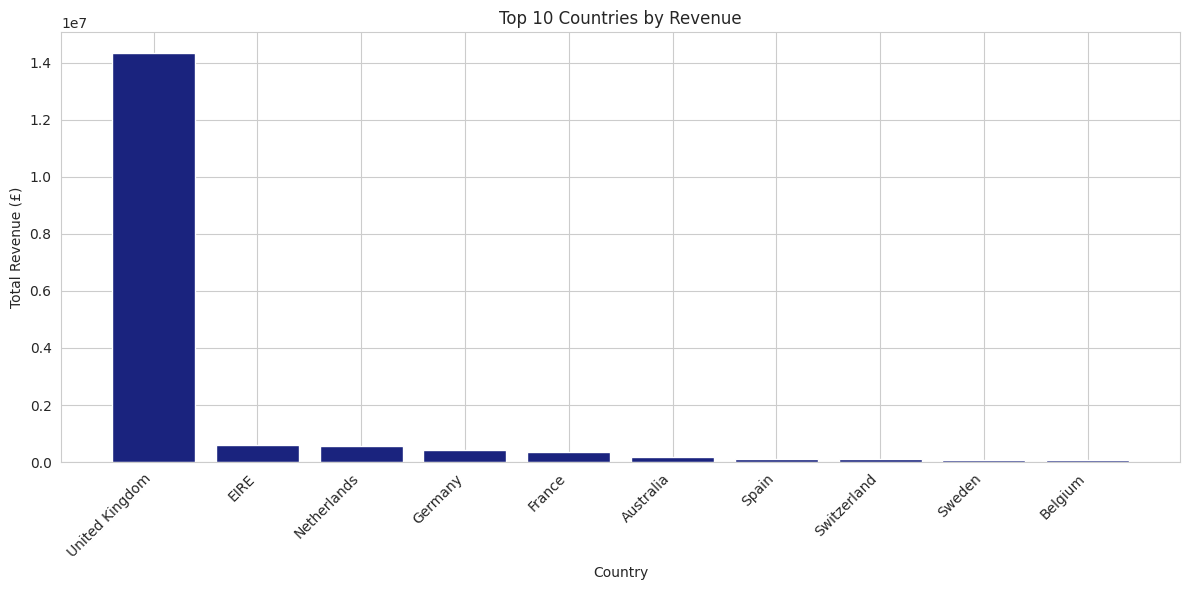

In [6]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.bar(country_revenue.index, country_revenue.values, color='#1a237e')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

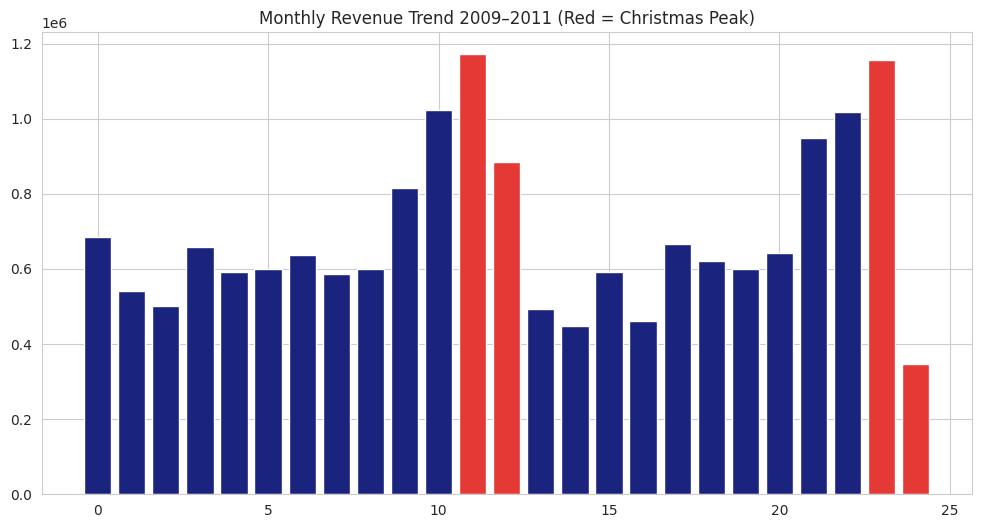

In [7]:
df['Year_Month'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('Year_Month')['Revenue'].sum()

plt.bar(range(len(monthly)), monthly.values,
        color=['#e53935' if i in [11, 12, 23, 24]
               else '#1a237e'
               for i in range(len(monthly))])
plt.title('Monthly Revenue Trend 2009–2011 (Red = Christmas Peak)')
plt.show()

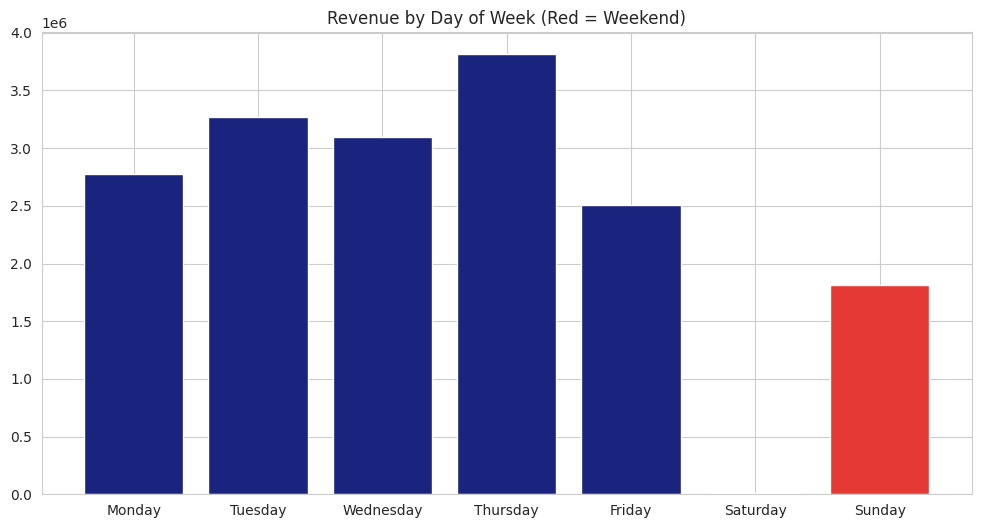

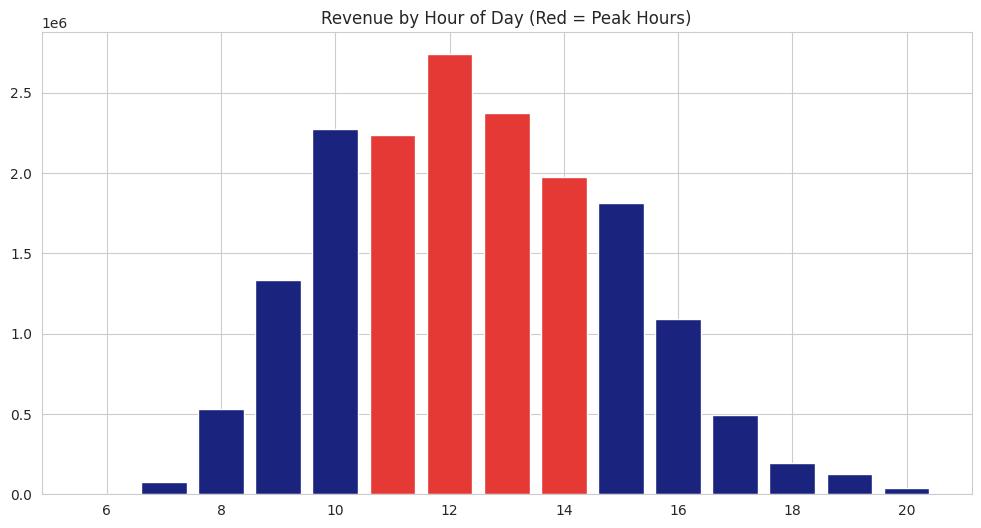

In [8]:
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_revenue = df.groupby('DayOfWeek')['Revenue'].sum().reindex(day_order)
hour_revenue = df.groupby('Hour')['Revenue'].sum()

# Day of week chart
plt.bar(day_revenue.index, day_revenue.values,
        color=['#e53935' if d in ['Saturday','Sunday'] else '#1a237e' for d in day_order])
plt.title('Revenue by Day of Week (Red = Weekend)')
plt.show()

# Hour of day chart
plt.bar(hour_revenue.index, hour_revenue.values,
        color=['#e53935' if h in [11,12,13,14] else '#1a237e' for h in hour_revenue.index])
plt.title('Revenue by Hour of Day (Red = Peak Hours)')
plt.show()

In [9]:
customer_stats = df.groupby('Customer ID').agg(
    Total_Orders=('Invoice', 'nunique'),
    Total_Revenue=('Revenue', 'sum'),
    Avg_Order_Value=('Revenue', 'mean'),
    Total_Items=('Quantity', 'sum')
).reset_index()

customer_stats['Segment'] = customer_stats['Total_Revenue'].apply(
    lambda x: 'VIP' if x > 5000
    else 'Returning' if x > 1000
    else 'New'
)

print(customer_stats['Segment'].value_counts())

Segment
New          3138
Returning    2077
VIP           658
Name: count, dtype: int64


In [10]:
monthly_df = df.groupby('Year_Month').agg(
    Monthly_Revenue=  ('Revenue',     'sum'),
    Monthly_Orders=   ('Invoice',     'nunique'),
    Monthly_Customers=('Customer ID', 'nunique'),
    Monthly_Items=    ('Quantity',    'sum'),
    Avg_Order_Value=  ('Revenue',     'mean')
).reset_index()

# Time index features
monthly_df['Month_Number']  = range(1, len(monthly_df) + 1)
monthly_df['Month_Of_Year'] = monthly_df['Year_Month'].dt.month
monthly_df['Year']          = monthly_df['Year_Month'].dt.year

# Seasonal flags (0 or 1)
monthly_df['Is_Christmas'] = monthly_df['Month_Of_Year'].apply(
    lambda x: 1 if x in [11, 12] else 0)
monthly_df['Is_Summer'] = monthly_df['Month_Of_Year'].apply(
    lambda x: 1 if x in [6, 7, 8] else 0)
monthly_df['Is_Q1'] = monthly_df['Month_Of_Year'].apply(
    lambda x: 1 if x in [1, 2, 3] else 0)

# Lag features  what did revenue look like 1, 2, 3 months ago?
monthly_df['Prev_Month_Revenue']   = monthly_df['Monthly_Revenue'].shift(1)
monthly_df['Prev_2_Month_Revenue'] = monthly_df['Monthly_Revenue'].shift(2)
monthly_df['Prev_3_Month_Revenue'] = monthly_df['Monthly_Revenue'].shift(3)

# Rolling average  smoothed trend over the past 3 months
monthly_df['Rolling_3_Month_Avg'] = monthly_df['Monthly_Revenue'].rolling(3).mean()

# Drop rows where lag/rolling features are NaN (the first few months)
monthly_df = monthly_df.dropna()

print("Monthly dataframe shape:", monthly_df.shape)
print("Features created:", monthly_df.columns.tolist())

Monthly dataframe shape: (22, 16)
Features created: ['Year_Month', 'Monthly_Revenue', 'Monthly_Orders', 'Monthly_Customers', 'Monthly_Items', 'Avg_Order_Value', 'Month_Number', 'Month_Of_Year', 'Year', 'Is_Christmas', 'Is_Summer', 'Is_Q1', 'Prev_Month_Revenue', 'Prev_2_Month_Revenue', 'Prev_3_Month_Revenue', 'Rolling_3_Month_Avg']


In [11]:
features = [
    'Month_Number', 'Month_Of_Year', 'Year',
    'Is_Christmas', 'Is_Summer', 'Is_Q1',
    'Prev_Month_Revenue', 'Prev_2_Month_Revenue',
    'Prev_3_Month_Revenue', 'Rolling_3_Month_Avg',
    'Monthly_Orders', 'Monthly_Customers',
    'Monthly_Items', 'Avg_Order_Value'
]

target = 'Monthly_Revenue'

X = monthly_df[features]   # inputs  (14 columns)
y = monthly_df[target]     # output  (1 column  what we want to predict)

# Hold back 20% of months as unseen test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=200,    # 200 trees in the forest
    max_depth=10,        # each tree can make at most 10 splits
    min_samples_split=2, # a node needs at least 2 samples to split
    min_samples_leaf=1,  # each leaf needs at least 1 sample
    random_state=42      # same random seed = reproducible results
)

rf_model.fit(X_train, y_train)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (17, 14)
Testing set size: (5, 14)


In [12]:
y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"R2 Score:  {round(r2, 4)}")
print(f"MAE:       £{round(mae, 2):,}")
print(f"RMSE:      £{round(rmse, 2):,}")
print(f"Model explains {round(r2 * 100, 2)}% of revenue variation")

R2 Score:  0.9058
MAE:       £55,344.32
RMSE:      £75,059.14
Model explains 90.58% of revenue variation


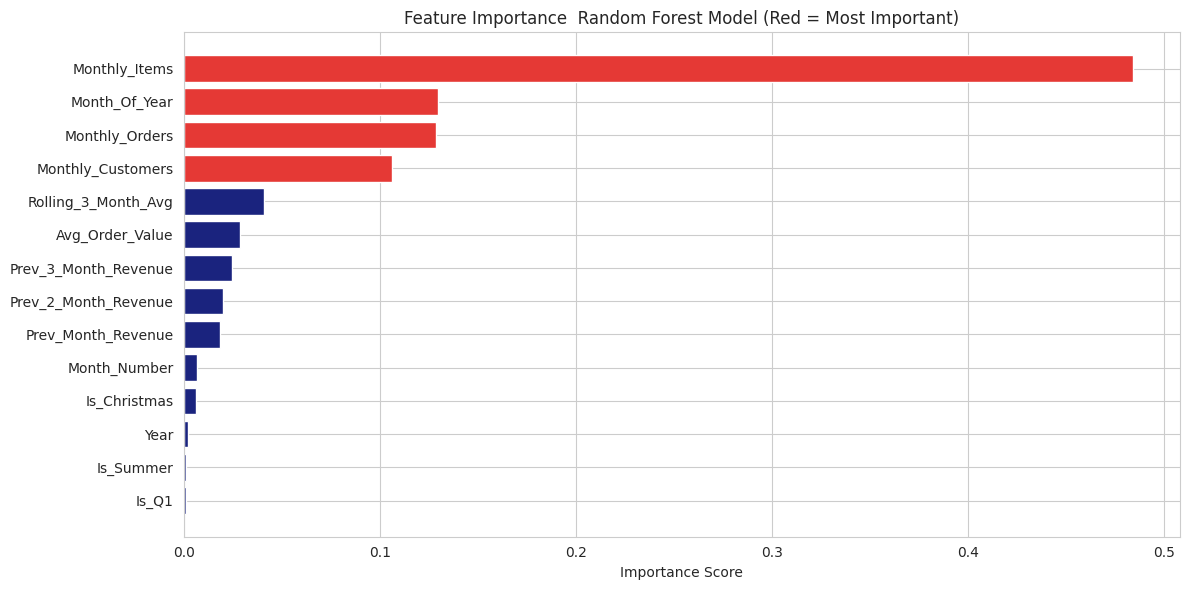

Top 5 most important features:
                Feature  Importance
9   Rolling_3_Month_Avg    0.040861
11    Monthly_Customers    0.106478
10       Monthly_Orders    0.128987
1         Month_Of_Year    0.130015
12        Monthly_Items    0.484081


In [13]:
feature_importance = pd.DataFrame({
    'Feature':    features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.barh(feature_importance['Feature'],
         feature_importance['Importance'],
         color=['#e53935' if imp > 0.1 else '#1a237e'
                for imp in feature_importance['Importance']])
plt.title('Feature Importance  Random Forest Model (Red = Most Important)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(feature_importance.tail(5)[['Feature', 'Importance']].to_string())

In [14]:
# Pull the last 3 months of actual revenue for lag features
last_month_revenue   = monthly_df['Monthly_Revenue'].iloc[-1]
last_2_month_revenue = monthly_df['Monthly_Revenue'].iloc[-2]
last_3_month_revenue = monthly_df['Monthly_Revenue'].iloc[-3]
rolling_avg          = monthly_df['Monthly_Revenue'].iloc[-3:].mean()

# Work out what the next calendar month is
last_month_number  = monthly_df['Month_Number'].iloc[-1]
last_month_of_year = monthly_df['Month_Of_Year'].iloc[-1]
last_year          = monthly_df['Year'].iloc[-1]

next_month_number   = last_month_number + 1
next_month_of_year  = (last_month_of_year % 12) + 1        # wraps 12 → 1
next_year           = last_year if next_month_of_year != 1 else last_year + 1

# Use historical averages for the volume features (we don't know the future values yet)
avg_orders       = monthly_df['Monthly_Orders'].mean()
avg_customers    = monthly_df['Monthly_Customers'].mean()
avg_items        = monthly_df['Monthly_Items'].mean()
avg_order_value  = monthly_df['Avg_Order_Value'].mean()

next_month_features = pd.DataFrame({
    'Month_Number':         [next_month_number],
    'Month_Of_Year':        [next_month_of_year],
    'Year':                 [next_year],
    'Is_Christmas':         [1 if next_month_of_year in [11, 12] else 0],
    'Is_Summer':            [1 if next_month_of_year in [6, 7, 8]  else 0],
    'Is_Q1':                [1 if next_month_of_year in [1, 2, 3]  else 0],
    'Prev_Month_Revenue':   [last_month_revenue],
    'Prev_2_Month_Revenue': [last_2_month_revenue],
    'Prev_3_Month_Revenue': [last_3_month_revenue],
    'Rolling_3_Month_Avg':  [rolling_avg],
    'Monthly_Orders':       [avg_orders],
    'Monthly_Customers':    [avg_customers],
    'Monthly_Items':        [avg_items],
    'Avg_Order_Value':      [avg_order_value],
})

prediction = rf_model.predict(next_month_features)[0]
print(f"PREDICTED REVENUE: £{prediction:,.2f}")

PREDICTED REVENUE: £575,102.38


In [18]:
def predict_sales_for_month(year, month):
    # Calculate Month_Number based on the historical data (monthly_df)
    # Assuming the sequence of months continues from the last month in monthly_df
    last_month_number_in_df = monthly_df['Month_Number'].iloc[-1]
    last_year_in_df = monthly_df['Year'].iloc[-1]
    last_month_of_year_in_df = monthly_df['Month_Of_Year'].iloc[-1]

    # Calculate the total number of months from the start of the dataset
    # up to the requested year and month.
    # This assumes the dataset starts in 2009-12 (Month_Number 1).
    # If the start month is different, this logic might need adjustment.
    # For this dataset, Month_Number 1 is 2009-12.
    # Month 1 of year X is (X - 2009) * 12 + (1 - 12) + 1. (adjusted)
    # Simpler: Count months from 2009-12 to the target month.

    # Calculate the total months elapsed from the start of the data (2009-12) to the target month.
    # The first month in `monthly_df` has Month_Number 4 (March 2010).
    # The actual first month (Dec 2009) would have Month_Number 1.
    # So, we can calculate the month number relative to Dec 2009.
    # Number of months from 2009-12 to (year, month):
    # If year = 2009, month = 12, then (2009 - 2009) * 12 + 12 = 12. Corrected to start from 1.
    # Month_Number = (year - start_year) * 12 + month - start_month_of_year + 1 (if start_month is 1)
    # Given monthly_df starts at Month_Number 4 (Mar 2010), we can infer first month (Dec 2009) is 1.
    # So for target (year, month), the Month_Number would be:
    month_number_for_prediction = (year - 2009) * 12 + month - 11 # Adjusting for Dec 2009 being month 1

    # Seasonal flags
    is_christmas = 1 if month in [11, 12] else 0
    is_summer = 1 if month in [6, 7, 8] else 0
    is_q1 = 1 if month in [1, 2, 3] else 0

    # Lag features - need to handle cases where prediction month is within the existing data
    # Or if we're predicting far into the future where lags can't be taken directly.
    # For simplicity here, we'll assume we are predicting the *next* month after the training data
    # or a month shortly after, where these lags can be taken from the end of `monthly_df`.
    # For more robust predictions further out, you'd need a rolling prediction mechanism.

    # Use the last 3 months of actual revenue from `monthly_df` for lag features
    last_month_revenue = monthly_df['Monthly_Revenue'].iloc[-1]
    last_2_month_revenue = monthly_df['Monthly_Revenue'].iloc[-2]
    last_3_month_revenue = monthly_df['Monthly_Revenue'].iloc[-3]
    rolling_avg = monthly_df['Monthly_Revenue'].iloc[-3:].mean()

    # Use historical averages for the volume features (we don't know the future values yet)
    avg_orders       = monthly_df['Monthly_Orders'].mean()
    avg_customers    = monthly_df['Monthly_Customers'].mean()
    avg_items        = monthly_df['Monthly_Items'].mean()
    avg_order_value  = monthly_df['Avg_Order_Value'].mean()

    next_month_features = pd.DataFrame({
        'Month_Number':         [month_number_for_prediction],
        'Month_Of_Year':        [month],
        'Year':                 [year],
        'Is_Christmas':         [is_christmas],
        'Is_Summer':            [is_summer],
        'Is_Q1':                [is_q1],
        'Prev_Month_Revenue':   [last_month_revenue],
        'Prev_2_Month_Revenue': [last_2_month_revenue],
        'Prev_3_Month_Revenue': [last_3_month_revenue],
        'Rolling_3_Month_Avg':  [rolling_avg],
        'Monthly_Orders':       [avg_orders],
        'Monthly_Customers':    [avg_customers],
        'Monthly_Items':        [avg_items],
        'Avg_Order_Value':      [avg_order_value],
    })

    prediction = rf_model.predict(next_month_features)[0]
    print(f"Predicted Revenue for {pd.to_datetime(f'{year}-{month}-01').strftime('%B %Y')}: £{prediction:,.2f}")


In [19]:
import ipywidgets as widgets
from IPython.display import display, clear_output

year_dropdown = widgets.Dropdown(
    options=[2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020],
    value=2012,
    description='Year:',
    style={'description_width': 'initial'}
)

month_dropdown = widgets.Dropdown(
    options=[('January',1),('February',2),('March',3),('April',4),
             ('May',5),('June',6),('July',7),('August',8),
             ('September',9),('October',10),('November',11),('December',12)],
    value=1,
    description='Month:',
    style={'description_width': 'initial'}
)

predict_button = widgets.Button(
    description='Predict Sales',
    button_style='success',
    icon='check',
    layout=widgets.Layout(width='200px', height='40px')
)

output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output(wait=True)
        predict_sales_for_month(year_dropdown.value, month_dropdown.value)

predict_button.on_click(on_button_click)

display(widgets.VBox([
    widgets.HBox([year_dropdown, month_dropdown]),
    predict_button,
    output
]))